Kaggle data source: https://www.kaggle.com/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/data

# Overview

This analysis explores the global epidemiology of Hantavirus using a comprehensive dataset sourced from Kaggle (with small additions/corrections to the outbreaks CSV file), covering clinical outcomes, geographic distribution, seasonal trends, virus strain characteristics, and outbreak history. The data was read from 10 CSV files into a SQLite database and queried using SQL alongside Python libraries including pandas, matplotlib, seaborn, and plotly for visualization.

The analysis is structured as follows: 
**Clinical & Outcomes** - How do patient demographics, virus strain, and reported symptoms relate to disease severity and fatality? 

**Geographic & Country-Level** - Which countries show the highest incidence of Hantavirus, and how do fatality rates and strain distributions differ by region?

**Temporal & Seasonal Trends** - Are there seasonal peaks in case counts? Has global incidence changed over time?

**Virus Strain Analysis** - Hoe do strains compare in transmissibility and lethality? 

In [294]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Phase 1: Creating Database
Read all 10 .csv files and save them to a SQLite database.

In [295]:
#1.
data_dictionary_df = pd.read_csv('data/data_dictionary.csv')
#2.
hv_andes_global_registry_df = pd.read_csv('data/Hantavirus_Andes_Global_Registry.csv')
#3.
hv_clinical_df = pd.read_csv('data/hantavirus_clinical.csv')
#4.
hv_country_yearly_df = pd.read_csv('data/hantavirus_country_yearly.csv')
#5.
hv_environmental_df = pd.read_csv('data/hantavirus_environmental.csv')
#6.
hv_master_df = pd.read_csv('data/hantavirus_master.csv')
#7.
hv_monthly_trends_df = pd.read_csv('data/hantavirus_monthly_trends.csv')
#8.
hv_outbreaks_df = pd.read_csv('data/hantavirus_outbreaks.csv')
#9.
hv_virus_strains_df = pd.read_csv('data/hantavirus_virus_strains.csv')
#10.
sources_metadata_df = pd.read_csv('data/sources_metadata.csv')

In [296]:
import sqlite3

#Connect to database file in project folder
conn = sqlite3.connect('hantavirus.db')

#Save dataframes as SQL tables
data_dictionary_df.to_sql('data_dictionary', conn, if_exists='replace', index=False)
hv_andes_global_registry_df.to_sql('hv_agr', conn, if_exists='replace', index=False)
hv_clinical_df.to_sql('hv_clinical', conn, if_exists='replace', index=False)
hv_country_yearly_df.to_sql('hv_country_yearly', conn, if_exists='replace', index=False)
hv_environmental_df.to_sql('hv_environmental', conn, if_exists='replace', index=False)
hv_master_df.to_sql('hv_master', conn, if_exists='replace', index=False)
hv_monthly_trends_df.to_sql('hv_monthly_trends', conn, if_exists='replace', index=False)
hv_outbreaks_df.to_sql('hv_outbreaks', conn, if_exists='replace', index=False)
hv_virus_strains_df.to_sql('hv_virus_strains', conn, if_exists='replace', index=False)
sources_metadata_df.to_sql('sources_metadata', conn, if_exists='replace', index=False)

print('Database saved!')

Database saved!


# Phase 2: Exploratory Data Analysis & SQL Querying

In [297]:
query1 = """
    SELECT age_group, gender
    FROM hv_clinical
    WHERE severity = 'Critical'
    ORDER BY age_group
"""
critical_cases = pd.read_sql_query(query1, conn)
print(critical_cases)

     age_group  gender
0         0-14  Female
1         0-14  Female
2         0-14  Female
3         0-14  Female
4         0-14  Female
...        ...     ...
1137       60+  Female
1138       60+  Female
1139       60+  Female
1140       60+  Female
1141       60+  Female

[1142 rows x 2 columns]


# Phase 3: Data Visualization

In [298]:
# Global dark theme settings
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})

print("Style loaded!")

Style loaded!


## Clinical & Outcomes
- What patient demographics (age, sex) are most associated with severe outcomes or death?
- Which virus strains have the highest case fatality rates?
- Do patients with certain symptoms (e.g. respiratory distress) have worse survival rates?

### Chart 1: Distribution of Severity by Age

In [299]:
severity_by_age = """
    SELECT age_group, gender, 
        CASE
            WHEN severity = 'Severe' THEN 2
            WHEN severity = 'Mild' THEN 0
            WHEN severity = 'Moderate' THEN 1
            WHEN severity = 'Critical' THEN 3
            ELSE NULL
        END AS severity_score
    FROM hv_clinical
    ORDER BY age_group, gender
"""

severity_dist = pd.read_sql_query(severity_by_age, conn)

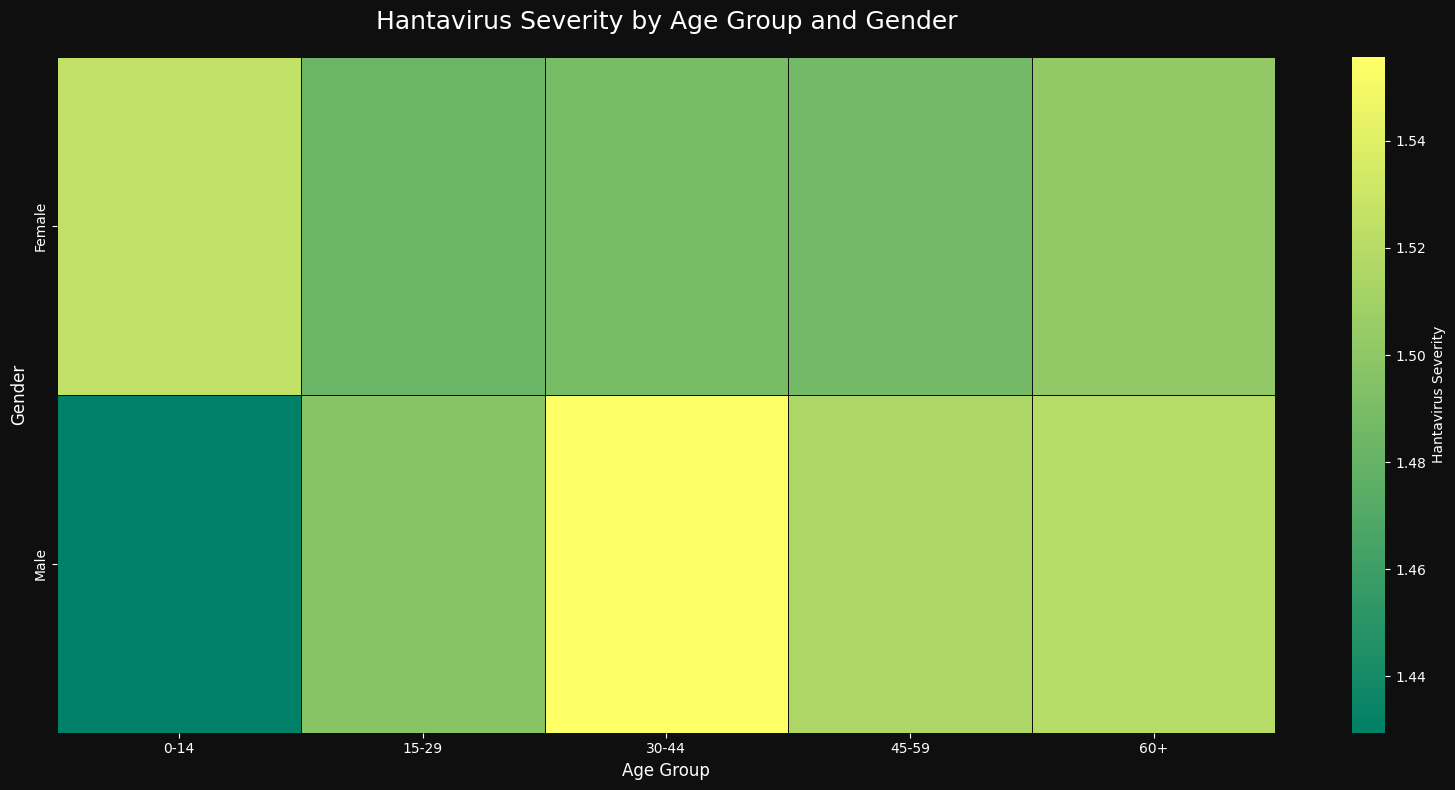

In [300]:
heatmap_pivot = severity_dist.pivot_table(
    index='gender', 
    columns='age_group',
    values='severity_score'
)

fig, ax = plt.subplots(figsize = (16,8))
sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap = 'summer',
    linewidth = 0.5, 
    linecolor = '#0f0f0f',
    annot = False,
    cbar_kws={'label': 'Hantavirus Severity'}
)

ax.set_title('Hantavirus Severity by Age Group and Gender', fontsize = 18, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Gender', fontsize=12)

plt.tight_layout()
plt.show()

### Chart 2: Distribution of Fatality Rate by Age & Gender

In [301]:
fatality_by_age = """
    SELECT 
        age_group, 
        gender, 
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS deceased
    FROM hv_clinical
    GROUP BY age_group, gender
    ORDER BY age_group, gender
"""

dist_fatality = pd.read_sql_query(fatality_by_age, conn)

dist_fatality['recovery_rate'] = (dist_fatality['recovered'])/(dist_fatality['recovered']+dist_fatality['deceased'])
dist_fatality['deceased_rate'] = 1-dist_fatality['recovery_rate']

dist_fatality

,age_group,gender,recovered,deceased,recovery_rate,deceased_rate
0,0-14,Female,695,126,0.846529,0.153471
1,0-14,Male,610,70,0.897059,0.102941
2,15-29,Female,583,80,0.879336,0.120664
3,15-29,Male,780,98,0.888383,0.111617
4,30-44,Female,677,102,0.869063,0.130937
5,30-44,Male,547,81,0.871019,0.128981
6,45-59,Female,726,120,0.858156,0.141844
7,45-59,Male,679,100,0.871630,0.128370
8,60+,Female,690,85,0.890323,0.109677
9,60+,Male,592,97,0.859216,0.140784


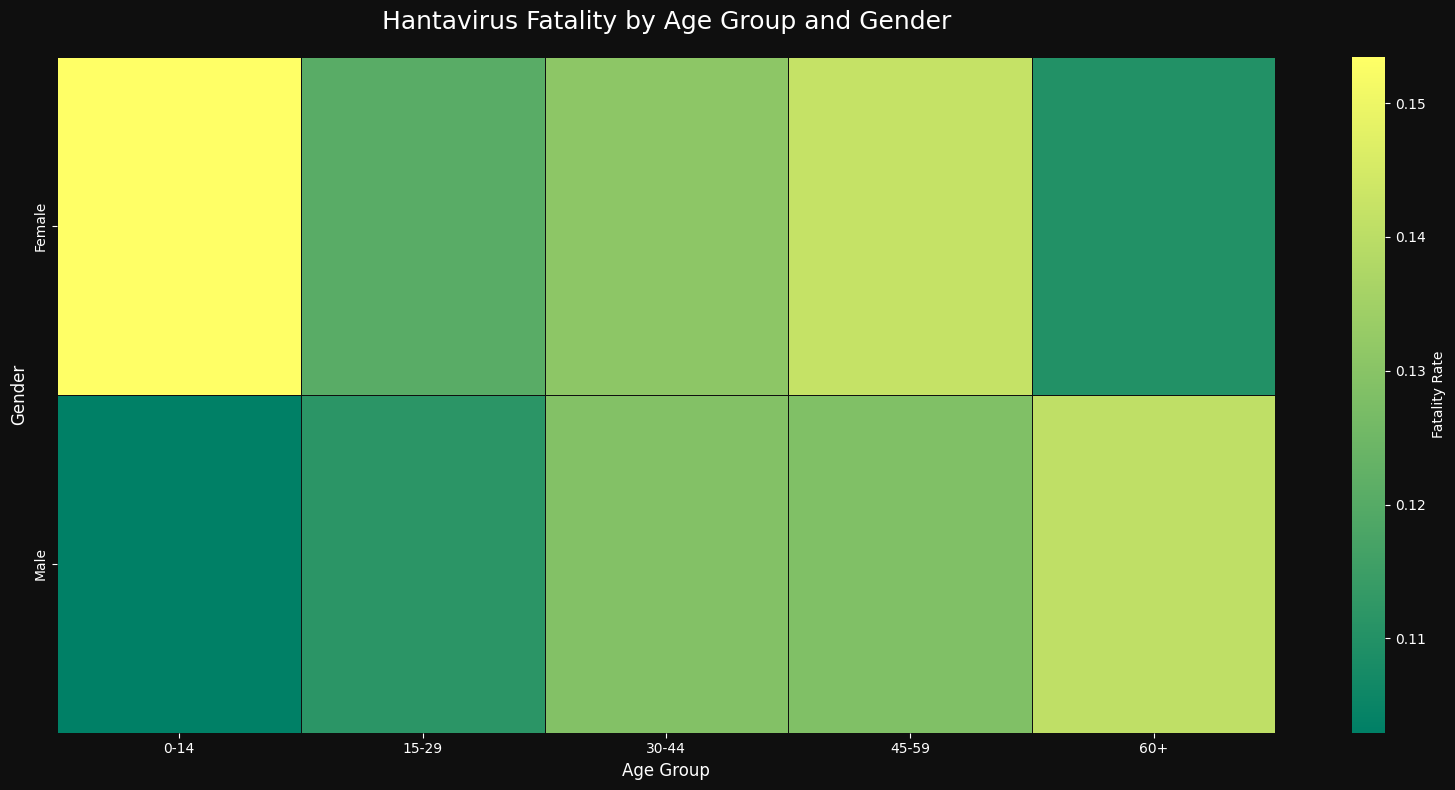

In [302]:
heatmap_pivot2 = dist_fatality.pivot_table(
    index='gender', 
    columns='age_group',
    values='deceased_rate'
)

fig, ax = plt.subplots(figsize = (16,8))
sns.heatmap(
    heatmap_pivot2,
    ax=ax,
    cmap = 'summer',
    linewidth = 0.5, 
    linecolor = '#0f0f0f',
    annot = False,
    cbar_kws={'label': 'Fatality Rate'}
)

ax.set_title('Hantavirus Fatality by Age Group and Gender', fontsize = 18, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Gender', fontsize=12)

plt.tight_layout()
plt.show()

### Chart 3: Distribution of Severity Per Virus Strain

In [303]:
dist_of_severity = """
    SELECT 
        COUNT(severity) AS severity_count, severity, virus_strain
    FROM hv_clinical
    GROUP BY severity, virus_strain
    ORDER BY virus_strain, 
        CASE severity
            WHEN 'Mild' THEN 1
            WHEN 'Moderate' THEN 2
            WHEN 'Severe' THEN 3
            WHEN 'Critical' THEN 4
        END
"""

severity_by_strain = pd.read_sql_query(dist_of_severity, conn)
#severity_by_strain

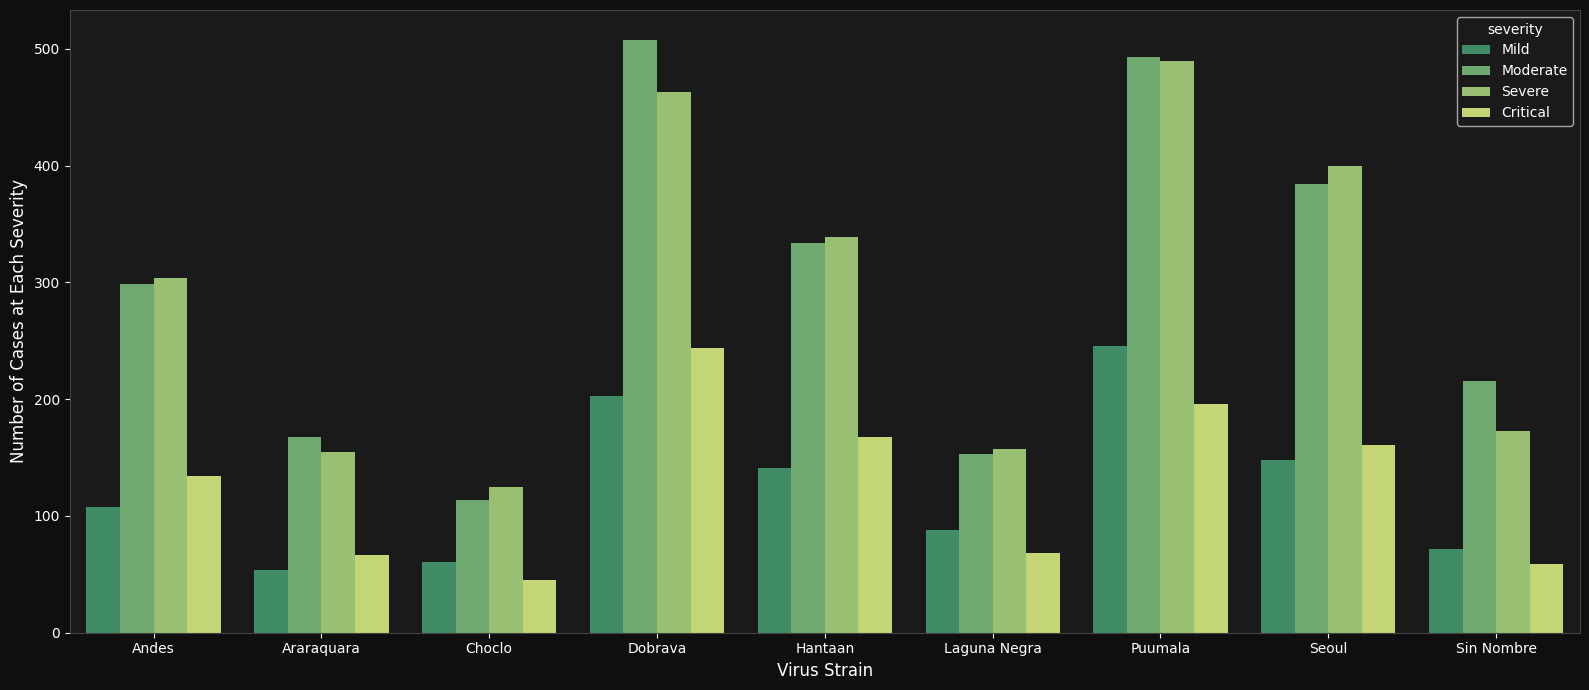

In [304]:
fig, ax = plt.subplots(figsize=(16,7))

sns.barplot(data=severity_by_strain, x='virus_strain', y='severity_count', hue='severity', palette = 'summer')
plt.xlabel('Virus Strain', fontsize=12)
plt.ylabel('Number of Cases at Each Severity', fontsize=12)

plt.tight_layout()
plt.show()

### Chart 4: Fatality Rate Per Virus Strain

In [305]:
dist_of_deceased = """
    SELECT
        virus_strain,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS deceased
    FROM hv_clinical
    GROUP BY virus_strain
    ORDER BY virus_strain
"""

deceased_by_strain = pd.read_sql_query(dist_of_deceased, conn)
deceased_by_strain['recovery_rate'] = (deceased_by_strain['recovered'])/(deceased_by_strain['recovered']+deceased_by_strain['deceased'])
deceased_by_strain['deceased_rate'] = 1-deceased_by_strain['recovery_rate']

deceased_by_strain

,virus_strain,recovered,deceased,recovery_rate,deceased_rate
0,Andes,587,258,0.694675,0.305325
1,Araraquara,304,140,0.684685,0.315315
2,Choclo,264,81,0.765217,0.234783
3,Dobrava,1298,120,0.915374,0.084626
4,Hantaan,920,62,0.936864,0.063136
5,Laguna Negra,343,123,0.736052,0.263948
6,Puumala,1416,9,0.993684,0.006316
7,Seoul,1067,26,0.976212,0.023788
8,Sin Nombre,380,140,0.730769,0.269231


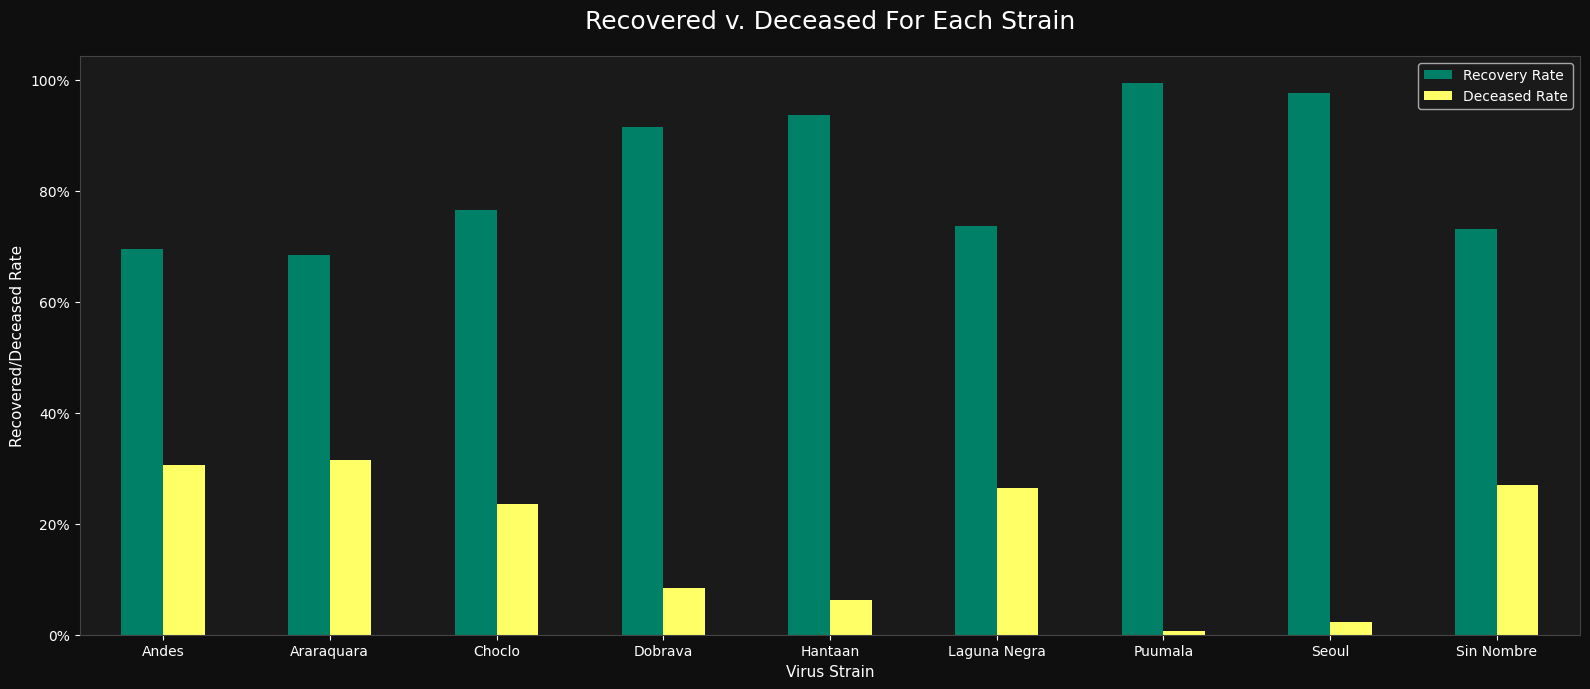

In [306]:
deceased_by_strain.plot(x='virus_strain', y=['recovery_rate', 'deceased_rate'], kind='bar', rot=0, figsize=(16,7), colormap='summer')

plt.title('Recovered v. Deceased For Each Strain', fontsize=18, pad=20)
plt.xlabel('Virus Strain', fontsize=11)
plt.ylabel('Recovered/Deceased Rate', fontsize=11)
plt.legend(['Recovery Rate', 'Deceased Rate'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

### Chart 5: Fatality Rate by Symptoms

In [307]:
print(hv_clinical_df.columns.to_list())

['syndrome', 'virus_strain', 'country_iso3', 'age_group', 'gender', 'incubation_days', 'severity', 'hospital_days', 'icu_admission', 'icu_days', 'ventilator_used', 'outcome', 'fever', 'myalgia', 'headache', 'cough', 'dyspnea', 'nausea', 'tachycardia', 'hypotension', 'pulmonary_edema', 'thrombocytopenia', 'back_pain', 'abdominal_pain', 'blurred_vision', 'petechiae', 'oliguria', 'proteinuria', 'hemorrhage']


In [308]:
symptoms = """
    SELECT  
        'Fever' AS symptom,
        fever AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE fever IS NOT NULL AND present = 1.0
    GROUP BY fever

    UNION ALL

    SELECT 
        'Myalgia' AS symptom, 
        myalgia AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE myalgia IS NOT NULL AND present = 1.0
    GROUP BY myalgia

    UNION ALL

    SELECT 
        'Headache' AS symptom, 
        headache AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE headache IS NOT NULL AND present = 1.0
    GROUP BY headache

    UNION ALL

    SELECT 
        'Cough' AS symptom, 
        cough AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE cough IS NOT NULL AND present = 1.0
    GROUP BY cough

    UNION ALL

    SELECT 
        'Dyspnea' AS symptom, 
        dyspnea AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE dyspnea IS NOT NULL AND present = 1.0
    GROUP BY dyspnea

    UNION ALL
    
    SELECT 
        'Nausea' AS symptom, 
        nausea AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE nausea IS NOT NULL AND present = 1.0
    GROUP BY nausea

    UNION ALL
    
    SELECT 
        'Tachycardia' AS symptom, 
        tachycardia AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE tachycardia IS NOT NULL AND present = 1.0
    GROUP BY tachycardia

    UNION ALL
    
    SELECT 
        'Hypotension' AS symptom, 
        hypotension AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE hypotension IS NOT NULL AND present = 1.0
    GROUP BY hypotension

    UNION ALL
    
    SELECT 
        'Pulmonary Edema' AS symptom, 
        pulmonary_edema AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE pulmonary_edema IS NOT NULL AND present = 1.0
    GROUP BY pulmonary_edema

    UNION ALL
    
    SELECT 
        'Thrombocytopenia' AS symptom, 
        thrombocytopenia AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE thrombocytopenia IS NOT NULL AND present = 1.0
    GROUP BY thrombocytopenia

    UNION ALL
    
    SELECT 
        'Back Pain' AS symptom, 
        back_pain AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE back_pain IS NOT NULL AND present = 1.0
    GROUP BY back_pain

    UNION ALL
    
    SELECT 
        'Abdominal Pain' AS symptom, 
        abdominal_pain AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE abdominal_pain IS NOT NULL AND present = 1.0
    GROUP BY abdominal_pain

    UNION ALL
    
    SELECT 
        'Blurred Vision' AS symptom, 
        blurred_vision AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE blurred_vision IS NOT NULL AND present = 1.0
    GROUP BY blurred_vision

    UNION ALL
    
    SELECT 
        'Petechiae' AS symptom, 
        petechiae AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE petechiae IS NOT NULL AND present = 1.0
    GROUP BY petechiae

    UNION ALL
    
    SELECT 
        'Oliguria' AS symptom, 
        oliguria AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE oliguria IS NOT NULL AND present = 1.0
    GROUP BY oliguria

    UNION ALL
    
    SELECT 
        'Proteinuria' AS symptom, 
        proteinuria AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE proteinuria IS NOT NULL AND present = 1.0
    GROUP BY proteinuria

    UNION ALL
    
    SELECT 
        'Hemorrhage' AS symptom, 
        hemorrhage AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE hemorrhage IS NOT NULL AND present = 1.0
    GROUP BY hemorrhage
"""

fatality_by_symptoms = pd.read_sql_query(symptoms, conn)

fatality_by_symptoms['symptom_recovery_rate'] = (fatality_by_symptoms['symptom_recovered'])/(fatality_by_symptoms['symptom_recovered']+fatality_by_symptoms['symptom_deceased'])
fatality_by_symptoms['symptom_deceased_rate'] = 1-fatality_by_symptoms['symptom_recovery_rate']

fatality_by_symptoms

,symptom,present,symptom_recovered,symptom_deceased,symptom_recovery_rate,symptom_deceased_rate
0,Fever,1.0,4351,633,0.872994,0.127006
1,Myalgia,1.0,1247,449,0.735259,0.264741
2,Headache,1.0,4217,605,0.874533,0.125467
3,Cough,1.0,1244,491,0.717003,0.282997
4,Dyspnea,1.0,1243,497,0.714368,0.285632
5,Nausea,1.0,4347,616,0.875882,0.124118
6,Tachycardia,1.0,1222,468,0.723077,0.276923
7,Hypotension,1.0,1239,497,0.713710,0.286290
8,Pulmonary Edema,1.0,1215,465,0.723214,0.276786
9,Thrombocytopenia,1.0,1205,476,0.716835,0.283165


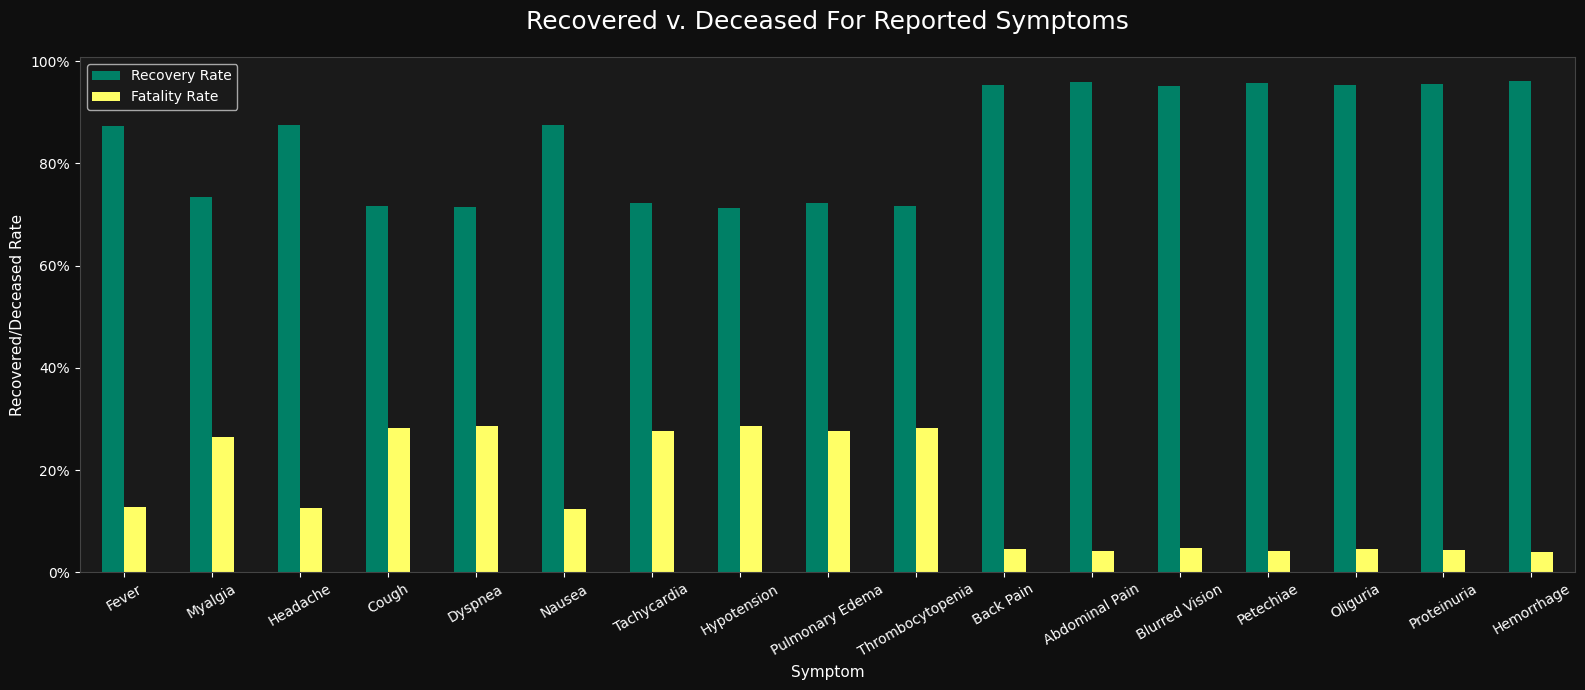

In [309]:
fatality_by_symptoms.plot(x='symptom', y=['symptom_recovery_rate', 'symptom_deceased_rate'], kind='bar', rot=30, figsize=(16,7), colormap='summer')

plt.title('Recovered v. Deceased For Reported Symptoms', fontsize=18, pad=20)
plt.xlabel('Symptom', fontsize=11)
plt.ylabel('Recovered/Deceased Rate', fontsize=11)
plt.legend(['Recovery Rate', 'Fatality Rate'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

## Geographic & Country-Level
- Which countries/regions report the most cases, and how has that changed over time?
- Are certain strains geographically concentrated, or do they overlap?
- Which countries have the highest v. lowest case fatality rates? Why might they differ?

In [310]:
tables_query = """
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name
"""

tables = pd.read_sql_query(tables_query, conn)
print(tables)

                name
0    data_dictionary
1             hv_agr
2        hv_clinical
3  hv_country_yearly
4   hv_environmental
5          hv_master
6  hv_monthly_trends
7       hv_outbreaks
8   hv_virus_strains
9   sources_metadata


### Charts 6, 7 & 8: Total Cases Per Country (Top 10), Fatality Rate by Country, & Yearly Case Trends by Country

In [311]:
print(hv_monthly_trends_df.columns.tolist())

['year', 'month', 'iso3', 'cases', 'deaths']


In [312]:
total_cases_by_country = """
    SELECT 
        country,
        SUM(confirmed_cases) AS total_cases,
        SUM(deaths) AS total_deaths
    FROM hv_country_yearly
    GROUP BY country
    ORDER BY total_cases DESC
"""

total_cases = pd.read_sql_query(total_cases_by_country, conn)

total_cases['fatality_rate'] = total_cases['total_deaths']/total_cases['total_cases']
print(total_cases)

cases_by_country = """
    SELECT 
        year,
        country,
        confirmed_cases
    FROM hv_country_yearly
    WHERE year >= 2015 AND confirmed_cases > 100
    ORDER BY country, year
"""

country_cases = pd.read_sql_query(cases_by_country, conn)
country_cases

           country  total_cases  total_deaths  fatality_rate
0            China      1177156         35685       0.030315
1           Russia       341356         13801       0.040430
2          Finland        81286           741       0.009116
3      South Korea        38537          1905       0.049433
4           Sweden        16014            57       0.003559
5          Germany         5524            42       0.007603
6           France         4229            16       0.003783
7          Belgium         4045            23       0.005686
8        Argentina         2943           842       0.286103
9          Croatia         2280            25       0.010965
10          Norway         2046             0       0.000000
11          Brazil         1674           601       0.359020
12        Slovenia         1374             2       0.001456
13           Chile         1321           419       0.317184
14   United States         1089           385       0.353535
15           Japan      

,year,country,confirmed_cases
0,2018,Argentina,111
1,2022,Argentina,104
2,2023,Argentina,146
3,2025,Argentina,118
4,2015,Belgium,118
...,...,...,...
82,2021,Sweden,308
83,2022,Sweden,387
84,2023,Sweden,440
85,2024,Sweden,371


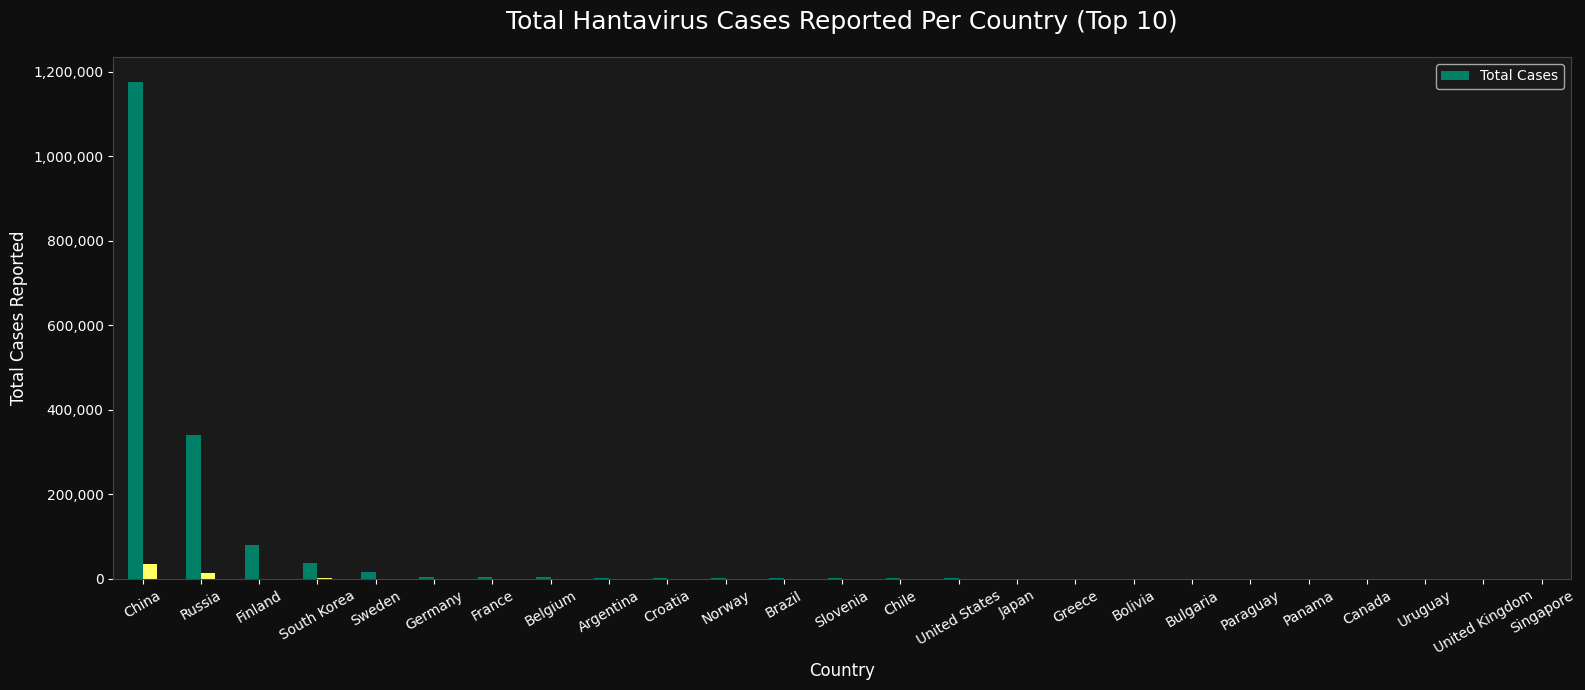

In [313]:
total_cases.plot(x='country', y=['total_cases', 'total_deaths'], kind='bar', rot=30, figsize=(16,7), colormap='summer')

plt.title('Total Hantavirus Cases Reported Per Country (Top 10)', fontsize=18, pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Cases Reported', fontsize=12)
plt.legend(['Total Cases'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [314]:
#ax = sns.barplot(data = total_cases, x='country', y='total_cases', color = 'green')

#plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
#plt.xticks(rotation=45)

#plt.tight_layout()
#plt.show()

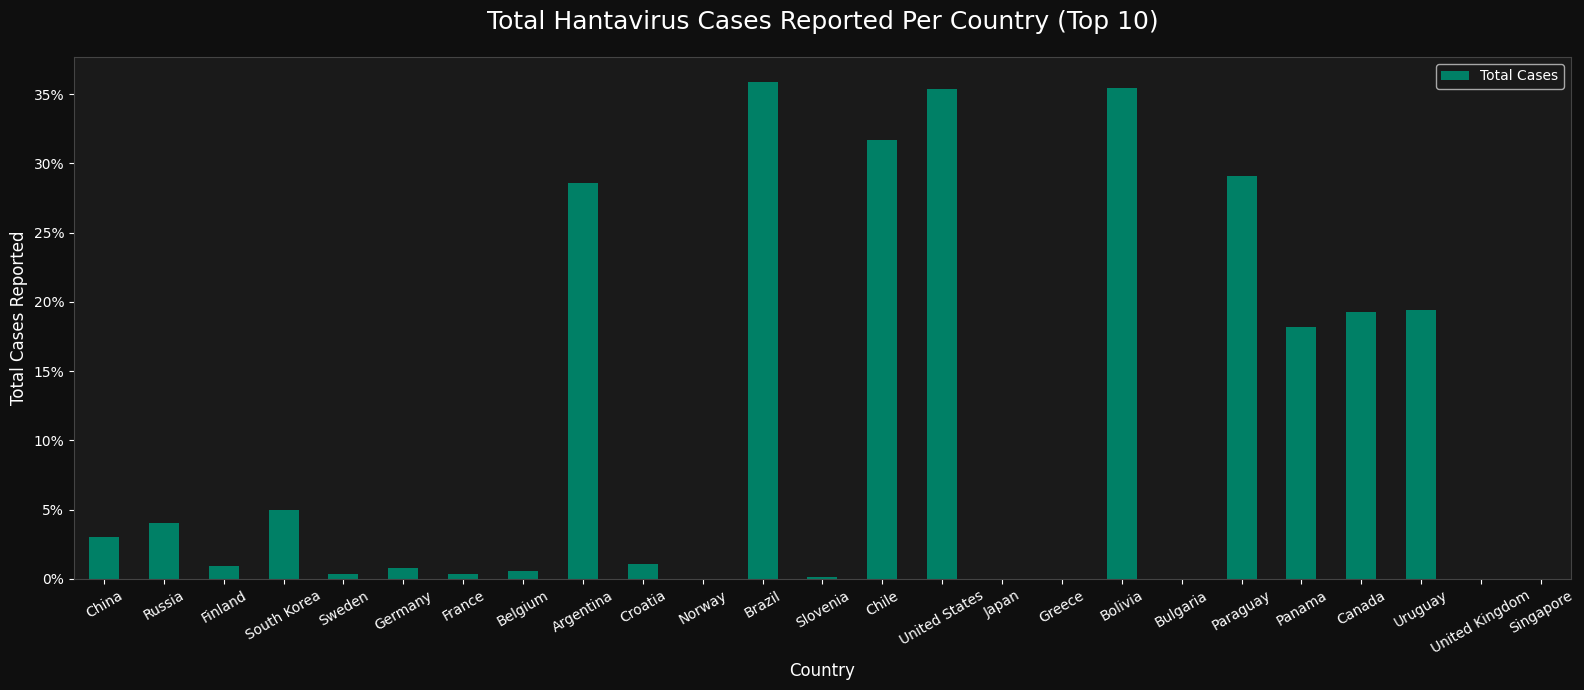

In [315]:
total_cases.plot(x='country', y='fatality_rate', kind='bar', rot=30, figsize=(16,7), colormap='summer')

plt.title('Total Hantavirus Cases Reported Per Country (Top 10)', fontsize=18, pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Cases Reported', fontsize=12)
plt.legend(['Total Cases'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

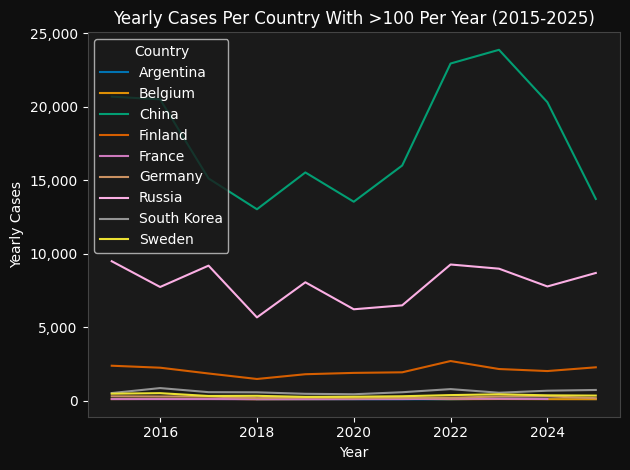

In [316]:
ax = sns.lineplot(data = country_cases, x='year', y='confirmed_cases', hue='country', palette = 'colorblind')

plt.title('Yearly Cases Per Country With >100 Per Year (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Yearly Cases')

legend = plt.gca().get_legend()
legend.set_title('Country')
sns.move_legend(ax, 'upper left')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Chart 9: Virus Strains by Region

In [317]:
strains_regions_query = """
    SELECT 
        DISTINCT a.virus_strain AS 'Virus Strain', 
        CASE a.country_iso3
            WHEN 'ARG' THEN 'Argentina'
            WHEN 'CHL' THEN 'Chile'
            WHEN 'BRA' THEN 'Brazil'
            WHEN 'PAN' THEN 'Panama'
            WHEN 'GRC' THEN 'Greece'
            WHEN 'HRV' THEN 'Croatia'
            WHEN 'SVN' THEN 'Slovenia'
            WHEN 'CHN' THEN 'China'
            WHEN 'KOR' THEN 'South Korea'
            WHEN 'PRY' THEN 'Paraguay'
            WHEN 'DEU' THEN 'Germany'
            WHEN 'FIN' THEN 'Finland'
            WHEN 'SWE' THEN 'Sweden'
            WHEN 'USA' THEN 'United States'
            ELSE NULL
        END as country, 
        COUNT(a.virus_strain) AS 'Case Count', b.latitude, b.longitude
    FROM hv_clinical AS a
    JOIN (
        SELECT DISTINCT iso3, latitude, longitude 
        FROM hv_country_yearly
    ) AS b ON a.country_iso3 = b.iso3
    GROUP BY virus_strain, country_iso3
    ORDER BY virus_strain
"""

strains_regions = pd.read_sql_query(strains_regions_query, conn)
strains_regions

,Virus Strain,country,Case Count,latitude,longitude
0,Andes,Argentina,457,-34.6,-58.4
1,Andes,Chile,388,-33.4,-70.7
2,Araraquara,Brazil,444,-15.8,-47.9
3,Choclo,Panama,345,9.0,-79.5
4,Dobrava,Greece,505,37.9,23.7
5,Dobrava,Croatia,439,45.8,16.0
6,Dobrava,Slovenia,474,46.1,14.5
7,Hantaan,China,437,39.9,116.4
8,Hantaan,South Korea,545,37.6,127.0
9,Laguna Negra,Paraguay,466,-25.3,-57.6


In [318]:
import plotly.express as px

In [319]:
# Add small random jitter to separate overlapping points
jitter = 0.8  # adjust this value to spread points more or less
strains_regions['lat_jitter'] = strains_regions['latitude'] + np.random.uniform(-jitter, jitter, len(strains_regions))
strains_regions['lon_jitter'] = strains_regions['longitude'] + np.random.uniform(-jitter, jitter, len(strains_regions))


fig = px.scatter_geo(strains_regions, 
                     lat='lat_jitter', 
                     lon='lon_jitter', 
                     color = 'Virus Strain',
                     size = 'Case Count',
                     hover_name='country',
                     hover_data={'lat_jitter': False, 'lon_jitter': False})

fig.show()

### Chart 10: Highest & Lowest Case Fatality Rates by Country

In [320]:
fatality_rates_by_region_query = """
    SELECT 
        country,
        SUM(confirmed_cases) AS total_cases,
        SUM(deaths) AS total_deaths, 
        (CAST(SUM(deaths) AS FLOAT)/ SUM(confirmed_cases)) AS fatality_rate
    FROM hv_country_yearly
    GROUP BY country
    ORDER BY fatality_rate DESC 
"""

fatality_rates_by_region = pd.read_sql_query(fatality_rates_by_region_query, conn)
fatality_rates_by_region

,country,total_cases,total_deaths,fatality_rate
0,Brazil,1674,601,0.359020
1,Bolivia,358,127,0.354749
2,United States,1089,385,0.353535
3,Chile,1321,419,0.317184
4,Paraguay,306,89,0.290850
5,Argentina,2943,842,0.286103
6,Uruguay,108,21,0.194444
7,Canada,114,22,0.192982
8,Panama,198,36,0.181818
9,South Korea,38537,1905,0.049433


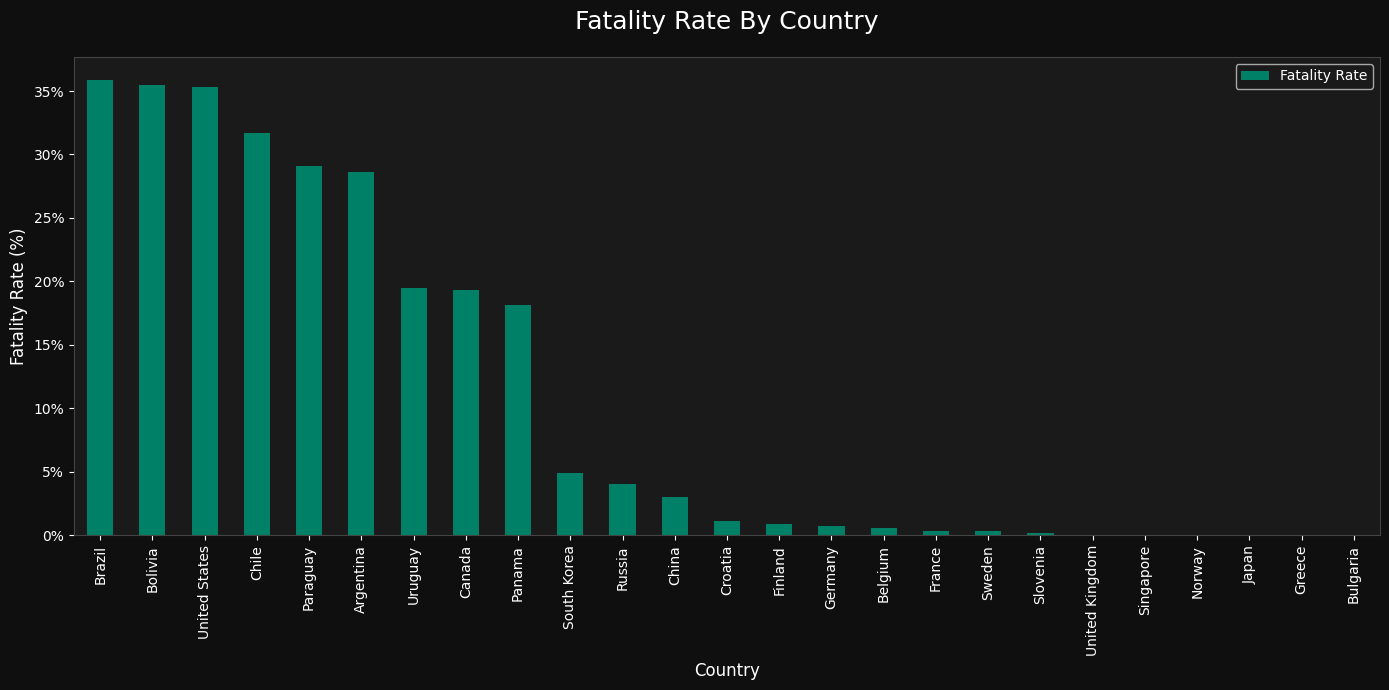

In [321]:
fig = fatality_rates_by_region.plot(kind = 'bar', x='country', y='fatality_rate', figsize=(14,7), colormap = 'summer')

plt.title('Fatality Rate By Country', fontsize=18, pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Fatality Rate (%)', fontsize=12)
plt.legend(['Fatality Rate'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

## Temporal & Seasonal Trends
- Are there seasonal peaks in cases? Do they vary by region?
- Has global incidence increased or decreased over the decades?
- Do outbreak sizes correlate with any environmental variables (temperature, rainfall, etc)?

### Charts 11 & 12: Seasonal Peaks in Cases

In [322]:
seasonal_peaks_query = """
    SELECT iso3, 
    CASE month
        WHEN 1 THEN 'January'
        WHEN 2 THEN 'February'
        WHEN 3 THEN 'March'
        WHEN 4 THEN 'April'
        WHEN 5 THEN 'May'
        WHEN 6 THEN 'June'
        WHEN 7 THEN 'July'
        WHEN 8 THEN 'August'
        WHEN 9 THEN 'September'
        WHEN 10 THEN 'October'
        WHEN 11 THEN 'November'
        WHEN 12 THEN 'December'
    END AS 'Month', 
    SUM(cases) AS 'Monthly Case Count'
    FROM hv_monthly_trends
    GROUP BY iso3, month
    ORDER BY iso3, CASE month
        WHEN 'January' THEN 1
        WHEN 'February' THEN 2
        WHEN 'March' THEN 3
        WHEN 'April' THEN 4
        WHEN 'May' THEN 5
        WHEN 'June' THEN 6
        WHEN 'July' THEN 7
        WHEN 'August' THEN 8
        WHEN 'September' THEN 9
        WHEN 'October' THEN 10
        WHEN 'November' THEN 11
        WHEN 'December' THEN 12
    END
"""

seasonal_peaks = pd.read_sql_query(seasonal_peaks_query, conn)
seasonal_peaks

,iso3,Month,Monthly Case Count
0,ARG,January,26
1,ARG,February,17
2,ARG,March,29
3,ARG,April,43
4,ARG,May,70
...,...,...,...
79,USA,August,29
80,USA,September,22
81,USA,October,24
82,USA,November,26


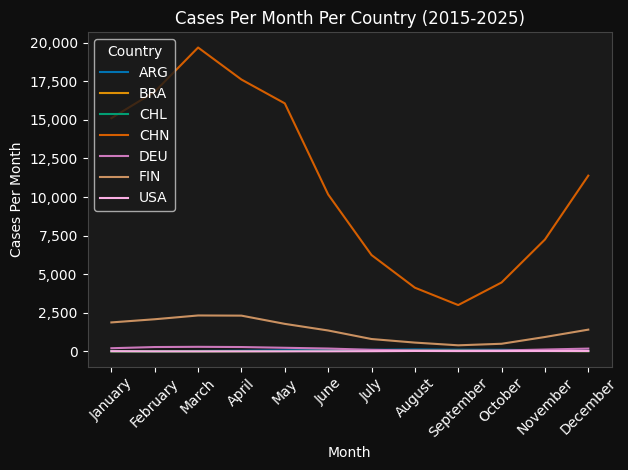

In [323]:
ax = sns.lineplot(data = seasonal_peaks, x='Month', y='Monthly Case Count', hue='iso3', palette='colorblind')

plt.title('Cases Per Month Per Country (2015-2025)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylabel('Cases Per Month')

legend = plt.gca().get_legend()
legend.set_title('Country')
sns.move_legend(ax, 'upper left')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [324]:
cases_by_month_query = """
    SELECT SUM(cases) AS monthly_cases, iso3, month
    FROM hv_monthly_trends
    GROUP BY month, iso3
    HAVING NOT iso3 = 'CHN' AND NOT iso3 = 'FIN'
    ORDER BY month
"""

cases_by_month = pd.read_sql_query(cases_by_month_query, conn)
cases_by_month.head()

,monthly_cases,iso3,month
0,26,ARG,1
1,4,BRA,1
2,4,CHL,1
3,207,DEU,1
4,17,USA,1


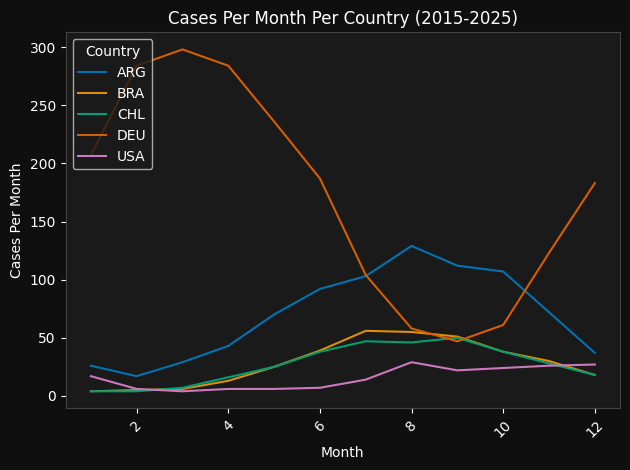

In [325]:
ax = sns.lineplot(data = cases_by_month, x='month', y='monthly_cases', hue='iso3', palette='colorblind')

plt.title('Cases Per Month Per Country (2015-2025)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylabel('Cases Per Month')

legend = plt.gca().get_legend()
legend.set_title('Country')
sns.move_legend(ax, 'upper left')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Chart 13: Incidence by Year Trend

In [326]:
incidence_year_query = """
    SELECT year, SUM(confirmed_cases) AS cases, deaths
    FROM hv_country_yearly
    GROUP BY year
    ORDER BY year
"""

incidence_year = pd.read_sql_query(incidence_year_query, conn)
incidence_year

,year,cases,deaths
0,1950,11220,387
1,1951,14687,308
2,1952,12859,429
3,1953,16997,494
4,1954,14410,539
...,...,...,...
71,2021,26249,24
72,2022,37105,31
73,2023,37159,37
74,2024,32218,27


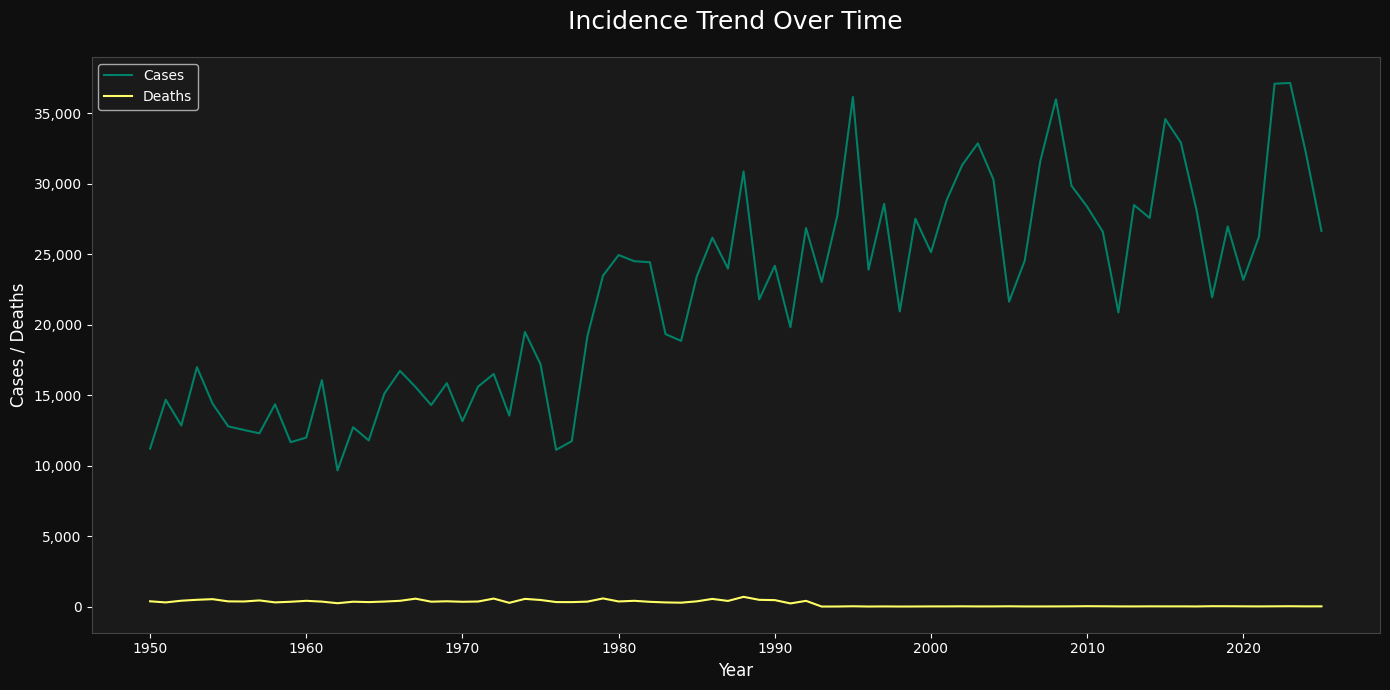

In [327]:
incidence_year.plot(kind = 'line', x='year', y=['cases', 'deaths'], figsize=(14,7), colormap = 'summer')

plt.title('Incidence Trend Over Time', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cases / Deaths', fontsize=12)
plt.legend(['Cases', 'Deaths'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [328]:
print(hv_environmental_df.columns.tolist())
print(hv_outbreaks_df.columns.tolist())

['iso3', 'region', 'latitude', 'longitude', 'biome', 'year', 'quarter', 'avg_temp_c', 'rainfall_mm', 'humidity_pct', 'ndvi', 'rodent_abundance_index', 'rodent_host_species', 'deforestation_km2', 'exposure_setting']
['year', 'quarter', 'country_iso3', 'location', 'virus_strain', 'syndrome', 'cases', 'deaths', 'cfr', 'description', 'source']


In [329]:
environment_of_outbreak_query = """
    SELECT *
    FROM hv_outbreaks AS a
    LEFT JOIN hv_environmental AS b on b.iso3 = a.country_iso3 AND a.year=b.year AND a.quarter=b.quarter
    WHERE a.year  >= 2010
    ORDER BY year
"""

environment_of_outbreak = pd.read_sql_query(environment_of_outbreak_query, conn)
environment_of_outbreak

,year,quarter,country_iso3,location,virus_strain,syndrome,cases,deaths,cfr,description,...,year,quarter,avg_temp_c,rainfall_mm,humidity_pct,ndvi,rodent_abundance_index,rodent_host_species,deforestation_km2,exposure_setting
0,2010,4.0,FIN,Nationwide,Puumala,HFRS,3237,3,0.001,Highest ever Finnish NE,...,2010.0,4.0,7.1,105.9,66.9,0.588,0.506,Myodes glareolus,2.27,Peri-urban
1,2012,2.0,DEU,Nationwide,Puumala,HFRS,2825,2,0.001,Germany second peak,...,2012.0,2.0,11.2,180.1,58.0,0.568,0.584,Myodes glareolus,2.68,Peri-urban
2,2012,2.0,USA,Yosemite NP,Sin Nombre,HPS,10,3,0.300,Tourism-linked cluster,...,2012.0,2.0,11.5,0.0,34.2,0.548,0.808,Peromyscus maniculatus,1.28,Rural
3,2012,2.0,USA,Yosemite NP,Sin Nombre,HPS,10,3,0.300,Tourism-linked cluster,...,2012.0,2.0,6.3,292.7,69.7,0.305,0.462,Peromyscus maniculatus,2.93,Rural
4,2017,NaN,ARG,Epuyén precursor,Andes,HPS,14,5,0.360,Patagonia cluster,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2018,4.0,ARG,Epuyén,Andes,HPS,34,11,0.320,Major H2H chain documented,...,2018.0,4.0,18.8,112.7,77.6,0.733,0.575,Oligoryzomys flavescens,2.44,Rural
6,2018,4.0,ARG,Epuyén,Andes,HPS,34,11,0.320,Major H2H chain documented,...,2018.0,4.0,15.9,440.1,62.7,0.660,0.547,Oligoryzomys longicaudatus,2.68,Rural
7,2019,2.0,DEU,Nationwide,Puumala,HFRS,1528,1,0.001,Mast year driven surge,...,2019.0,2.0,10.7,270.5,61.9,0.509,0.450,Myodes glareolus,5.26,Rural
8,2023,1.0,BOL,Santa Cruz,Andes-like,HPS,18,7,0.390,Bolivian rural outbreak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2025,2.0,ARG,Multiple provinces,Andes,HPS,72,22,0.310,Climate-linked surge,...,2025.0,2.0,17.2,286.9,67.9,0.460,1.000,Oligoryzomys flavescens,2.43,Peri-urban


The outbreak sample size seems too small/too incomplete to make any claims on the data. The only quick noticeable trend is that rodent host species differs by region (to be expected) and there are more rural exposure settings than there are peri-urban, but that could also be associated with the differences between South American environments and European environments. 

The other noticeable trend is that HFRS (Hemorrhagic Fever with Renal Syndrome) has a much larger outbreak size in terms of cases than does HPS (Hantavirus Pulmonary Syndrome). Both are life-threatening viral syndromes caused by Hantaviruses, so this could largely be a result of the rural v. peri-urban exposure setting difference.

## Virus Strain Analysis
- How do different strains compare in transmissibility and lethality?
- Are newer strains more or less deadly than older ones?

### Chart 14 & 15: Transmissibility & Lethality of Strains

In [330]:
print(hv_virus_strains_df.columns.tolist())
print(hv_clinical_df.columns.tolist())

['strain_name', 'abbreviation', 'order', 'family', 'genus', 'associated_syndrome', 'primary_rodent_host', 'geographic_range', 'human_to_human', 'genome_structure', 'genbank_accession', 'year_identified']
['syndrome', 'virus_strain', 'country_iso3', 'age_group', 'gender', 'incubation_days', 'severity', 'hospital_days', 'icu_admission', 'icu_days', 'ventilator_used', 'outcome', 'fever', 'myalgia', 'headache', 'cough', 'dyspnea', 'nausea', 'tachycardia', 'hypotension', 'pulmonary_edema', 'thrombocytopenia', 'back_pain', 'abdominal_pain', 'blurred_vision', 'petechiae', 'oliguria', 'proteinuria', 'hemorrhage']


In [331]:
strains_transmission_query = """
    SELECT 
        b.year_identified,
        b.strain_name, 
        b.geographic_range,
        SUM(CASE WHEN a.outcome = 'Recovered' THEN 1 ELSE 0 END) AS recovered,
        SUM(CASE WHEN a.outcome = 'Deceased' THEN 1 ELSE 0 END) AS deceased,
        COUNT(a.virus_strain) AS cases
    FROM hv_clinical AS a
    JOIN (
        SELECT 
            DISTINCT year_identified, strain_name, geographic_range
        FROM hv_virus_strains
    ) AS b ON a.virus_strain = b.strain_name
    GROUP BY a.virus_strain
    ORDER BY year_identified, a.virus_strain
"""

strains_transmission = pd.read_sql_query(strains_transmission_query, conn)
strains_transmission['fatality_rate'] = strains_transmission['deceased']/strains_transmission['cases']
strains_transmission['recovery_rate'] = 1-strains_transmission['fatality_rate']

strains_transmission

,year_identified,strain_name,geographic_range,recovered,deceased,cases,fatality_rate,recovery_rate
0,1976,Hantaan,Asia,920,62,982,0.063136,0.936864
1,1980,Puumala,Europe,1416,9,1425,0.006316,0.993684
2,1980,Seoul,Global,1067,26,1093,0.023788,0.976212
3,1993,Sin Nombre,North America,380,140,520,0.269231,0.730769
4,1995,Andes,South America,587,258,845,0.305325,0.694675
5,1997,Laguna Negra,South America,343,123,466,0.263948,0.736052
6,1999,Choclo,Central America,264,81,345,0.234783,0.765217
7,2000,Araraquara,Brazil,304,140,444,0.315315,0.684685


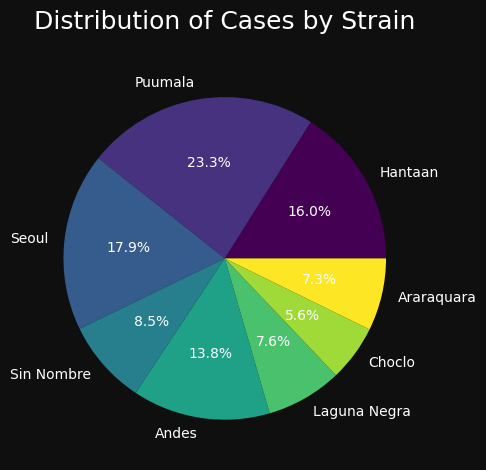

In [332]:
strains_transmission.plot(kind='pie', y='cases', labels = strains_transmission['strain_name'], autopct='%1.1f%%', colormap = 'viridis', legend=False)

plt.title('Distribution of Cases by Strain', fontsize=18, pad=20)
plt.ylabel('')

plt.tight_layout()
plt.show()

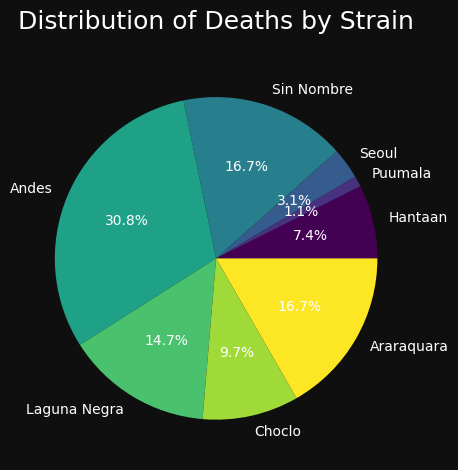

In [333]:
strains_transmission.plot(kind='pie', y='deceased', labels = strains_transmission['strain_name'], autopct='%1.1f%%', colormap = 'viridis', legend=False)

plt.title('Distribution of Deaths by Strain', fontsize=18, pad=20)
plt.ylabel('')

plt.tight_layout()
plt.show()

# Statistical Analysis & Predictive Modeling

- Chi-square for each categorical variable vs. outcome
- Logistic regression combining the significant variables
- Linear, polynomial, and Holt's linear smoothing to predict number of cases over years. 

In [334]:
from scipy.stats import chi2_contingency

In [335]:
# Strain predicting outcome
strain_outcome_ct = pd.crosstab(hv_clinical_df['virus_strain'], hv_clinical_df['outcome'])

# chi-squared, p-value, degrees of freedom, expected values if variables were unrelated
chi2, p, dof, expected = chi2_contingency(strain_outcome_ct)
print(f'Strain vs. Outcome p-value: {p}')


#Gender predicting outcome
gender_outcome_ct = pd.crosstab(hv_clinical_df['gender'], hv_clinical_df['outcome'])

chi2, p, dof, expected = chi2_contingency(gender_outcome_ct)
print(f'Gender vs. Outcome p-value: {p}')


#Age predicting outcome
age_outcome_ct = pd.crosstab(hv_clinical_df['age_group'], hv_clinical_df['outcome'])

chi2, p, dof, expected = chi2_contingency(gender_outcome_ct)
print(f'Age Group vs. Outcome p-value: {p}')

Strain vs. Outcome p-value: 1.7080309972816935e-198


Gender vs. Outcome p-value: 0.2039140559060134
Age Group vs. Outcome p-value: 0.2039140559060134


In [336]:
from sklearn.linear_model import LogisticRegression
import statsmodels.formula.api as smf

In [337]:
hv_clinical_copy = hv_clinical_df.copy()
hv_clinical_copy['deceased'] = (hv_clinical_copy['outcome'] == 'Deceased').astype(int)

#Baseline is age 0-14, female, Andes
logit_formula = 'deceased ~ C(age_group) + C(gender) + C(virus_strain)'

logit_model = smf.logit(logit_formula, data=hv_clinical_copy).fit(disp=False, maxiter=200)

print(logit_model.summary())
print(f'Pseudo R-squared: {logit_model.prsquared:.4f}')
print(f'LLR p-value: {logit_model.llr_pvalue:.4f}')

#converged: True -- model is reliable
#LLR p-value is practically zero, meaning the model is statistically significant.

                           Logit Regression Results                           
Dep. Variable:               deceased   No. Observations:                 7538
Model:                          Logit   Df Residuals:                     7524
Method:                           MLE   Df Model:                           13
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.1738
Time:                        11:03:59   Log-Likelihood:                -2373.3
converged:                       True   LL-Null:                       -2872.5
Covariance Type:            nonrobust   LLR p-value:                3.967e-205
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -0.8083      0.109     -7.434      0.000      -1.021      -0.595
C(age_group)[T.15-29]               0.0044      0.120      0.037    

In [338]:
odds_ratios = np.exp(logit_model.params)
#print(odds_ratios)

conf = logit_model.conf_int()
conf.columns = ['2.5%', '97.5%']

odds_table = pd.DataFrame({
    'Odds Ratio': np.exp(logit_model.params),
    '2.5%': np.exp(conf['2.5%']),
    '97.5%': np.exp(conf['97.5%']),
    'p-value': logit_model.pvalues
}).round(4)

# Odds ratios are deaths:recoveries. So, for the intercept, an odds ratio of 0.4456 means that for every 1 death, there is ~2.24 recoveries. 

print(odds_table)

                                 Odds Ratio    2.5%   97.5%  p-value
Intercept                            0.4456  0.3601  0.5514   0.0000
C(age_group)[T.15-29]                1.0044  0.7938  1.2709   0.9707
C(age_group)[T.30-44]                1.2040  0.9536  1.5202   0.1187
C(age_group)[T.45-59]                0.9907  0.7939  1.2362   0.9338
C(age_group)[T.60+]                  1.0513  0.8334  1.3262   0.6728
C(gender)[T.Male]                    0.8917  0.7700  1.0326   0.1257
C(virus_strain)[T.Araraquara]        1.0605  0.8265  1.3607   0.6444
C(virus_strain)[T.Choclo]            0.6985  0.5226  0.9335   0.0153
C(virus_strain)[T.Dobrava]           0.2082  0.1640  0.2643   0.0000
C(virus_strain)[T.Hantaan]           0.1512  0.1123  0.2034   0.0000
C(virus_strain)[T.Laguna Negra]      0.8216  0.6373  1.0593   0.1296
C(virus_strain)[T.Puumala]           0.0144  0.0073  0.0282   0.0000
C(virus_strain)[T.Seoul]             0.0550  0.0363  0.0834   0.0000
C(virus_strain)[T.Sin Nombre]     

In [339]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.holtwinters import Holt

In [340]:
model_data_query = """
    SELECT year, SUM(confirmed_cases) AS yearly_cases
    FROM hv_country_yearly
    GROUP BY year
    ORDER BY year
"""

model_data = pd.read_sql_query(model_data_query, conn)
model_data

,year,yearly_cases
0,1950,11220
1,1951,14687
2,1952,12859
3,1953,16997
4,1954,14410
...,...,...
71,2021,26249
72,2022,37105
73,2023,37159
74,2024,32218


### Linear Regression:

In [341]:
future_years = np.array([2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)

year_df = model_data.dropna(subset=['year', 'yearly_cases']).copy()

if len(year_df) < 2:
    raise ValueError('Linear regression needs at least 2 yearly observations.')

x = year_df[['year']].values
y = year_df['yearly_cases'].values

lin_model = LinearRegression()
lin_model.fit(x, y)

r_squared = lin_model.score(x, y)
predicted_values = lin_model.predict(future_years)

linear_predictions_df = pd.DataFrame({
    'year': future_years.ravel(),
    'yearly_cases_lin': np.maximum(0, predicted_values).round().astype(int),
    'r_squared_linear': round(r_squared, 3)
})

linear_predictions_df


,year,yearly_cases_lin,r_squared_linear
0,2026,33056,0.7
1,2027,33340,0.7
2,2028,33623,0.7
3,2029,33906,0.7
4,2030,34190,0.7


### Polynomial Regression:

In [342]:
if len(year_df) < 2:
    raise ValueError('Polynomial regression needs at least 2 yearly observations.')

x = year_df[['year']].values
y = year_df['yearly_cases'].values

poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(x,y)

r_squared = poly_model.score(x, y)
predicted_values = poly_model.predict(future_years)

poly_predictions_df = pd.DataFrame({
    'year': future_years.ravel(),
    'yearly_cases_poly': np.maximum(0, predicted_values).round().astype(int),
    'r_squared_poly': round(r_squared, 3)
})

poly_predictions_df

,year,yearly_cases_poly,r_squared_poly
0,2026,27832,0.736
1,2027,27440,0.736
2,2028,27010,0.736
3,2029,26541,0.736
4,2030,26033,0.736


### Holt's Linear Exponential Smoothing:

In [343]:
if len(year_df) < 2:
    raise ValueError('Holt exponential smoothing needs at least 2 yearly observations.')

y = year_df['yearly_cases'].values

exp_model = Holt(y).fit(optimized=True)
forecast = exp_model.forecast(len(future_years))

# MAE on historical data
fitted = exp_model.fittedvalues
mae = np.mean(np.abs(fitted - y))

alpha = exp_model.params['smoothing_level']
beta = exp_model.params['smoothing_trend']

exp_df = pd.DataFrame({
    'year': future_years.ravel(),
    'yearly_cases_exp': np.maximum(0, forecast).round().astype(int),
    'mae': round(mae),
    'alpha': round(alpha, 3),
    'beta': round(beta, 3)
})

exp_df

,year,yearly_cases_exp,mae,alpha,beta
0,2026,28910,3863,0.699,0.088
1,2027,28911,3863,0.699,0.088
2,2028,28912,3863,0.699,0.088
3,2029,28913,3863,0.699,0.088
4,2030,28913,3863,0.699,0.088


### Chart 16: Case Incidence Forecasting

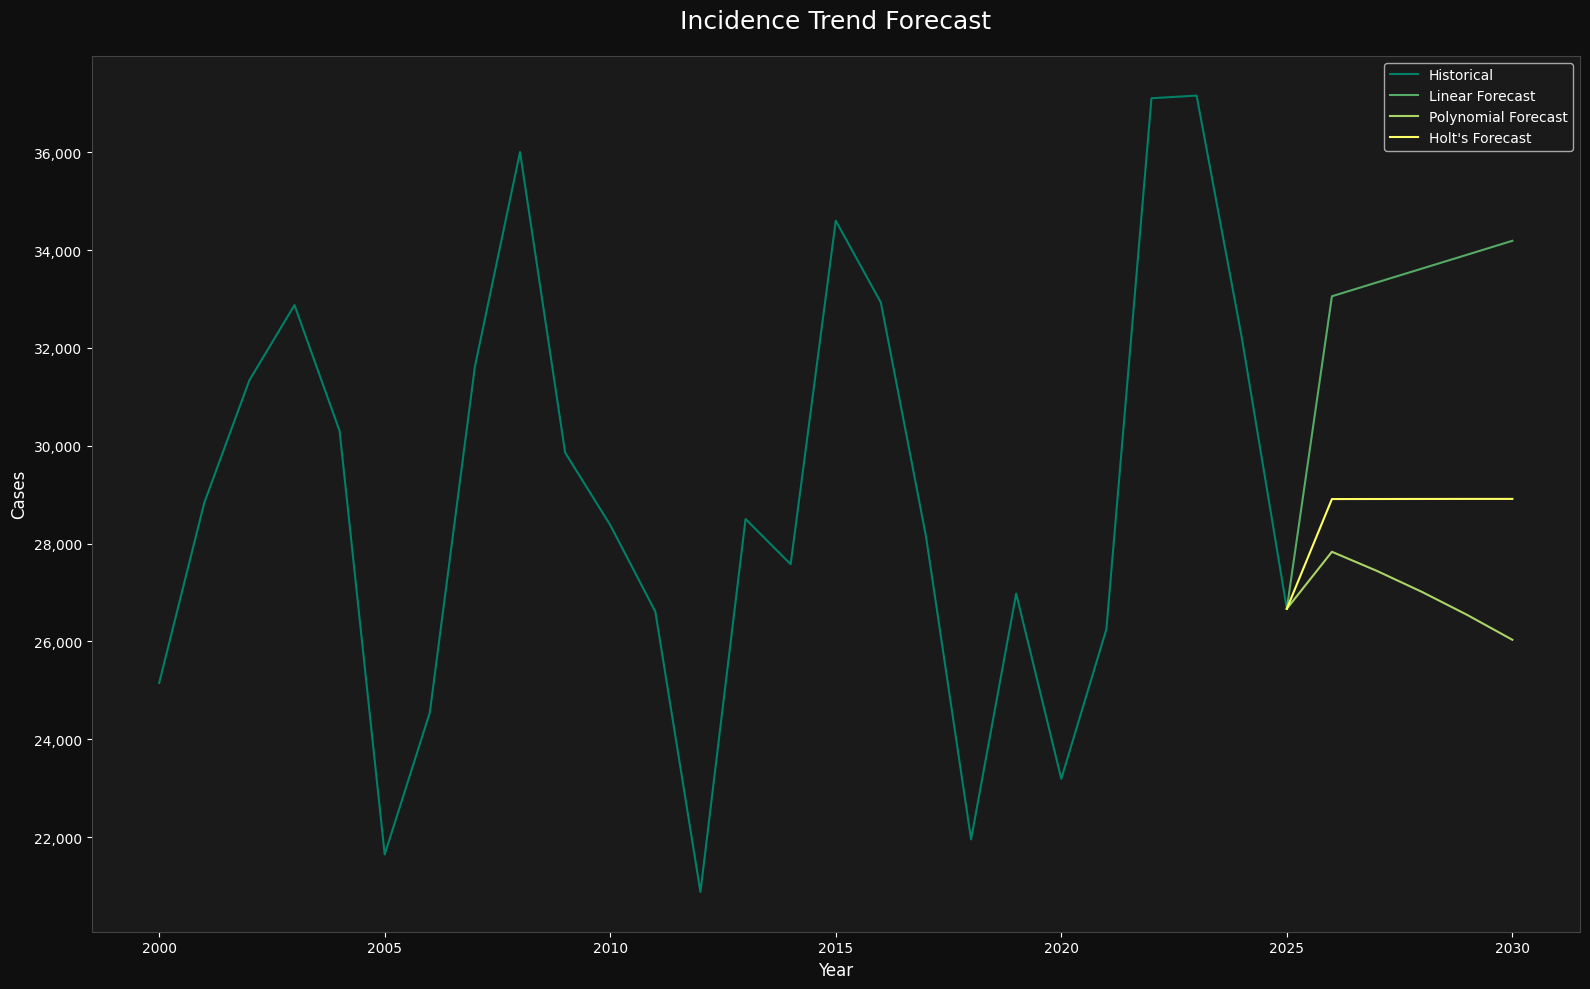

In [344]:
future_df = exp_df.copy()
future_df['yearly_cases_poly'] = poly_predictions_df['yearly_cases_poly']
future_df['yearly_cases_lin'] = linear_predictions_df['yearly_cases_lin']

future_df2 = pd.concat([model_data, future_df.copy()], axis=0, ignore_index = True)

future_df2.at[75, 'yearly_cases_exp'] = future_df2.at[75, 'yearly_cases']
future_df2.at[75, 'yearly_cases_poly'] = future_df2.at[75, 'yearly_cases']
future_df2.at[75, 'yearly_cases_lin'] = future_df2.at[75, 'yearly_cases']
future_df2 = future_df2[future_df2['year'] >= 2000]

future_df2.plot(kind = 'line', x = 'year', y = ['yearly_cases', 'yearly_cases_lin', 'yearly_cases_poly', 'yearly_cases_exp'], figsize=(16,10), colormap = 'summer')

plt.title('Incidence Trend Forecast', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cases', fontsize=12)
plt.legend(['Historical', 'Linear Forecast', 'Polynomial Forecast', "Holt's Forecast"])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# Conclusion

Across all four areas of analysis, several meaningful patterns emerge. 

### Key Takeaways
- Men ages 30+ appear to have the most consistently severe outcomes and highest Hantavirus incidence. However, females ages 0-14 have the highest fatality rates. 
- The Andes, Araraquara, Sin Nombre, and Laguna Negra strains have the highest fatality rates, which the Puumala strain has the lowest fatality rate, which a rate of 0.6%. 
- Although fatality rates varied widely by symptom, symptoms such as dyspnea (extreme shortness of breath), hypotension (abnormally low blood pressure), and thrombocytopenia (abnormally low number of platelets in blood) correlate with higher fatality rates, while symptoms such as back pain, abdominal pain, and hemorrhage (uncontrolled bleeding) correlate with lower fatality rates. The lower rate associated with hemorrhage may reflect the fact that hemorrhage is a defining characteristic of HFRS (Eurasian strains) and is not as common in HPS (American strains). 
- Strain distributions show clear regional clustering, with South American strains associated with HPS and Eurasian strains more commoning driving HFRS outbreaks. HFRS outbreaks tend to be substantially larger, likely reflecting differences in exposure settings (rural v. peri-urban). 
- In chi-square testing, we achieved a p-value of ~0.00 when testing virus strain vs. outcome, giving us strong evidence to conclude a relationship between virus strain and patient outcome. 

### Limitations & Next Steps
- In analysis, an inconsistency was found in outbreak data--specifically, the date listed was incorrect. While this was the only inconsistency found, it should be noted, and any findings should be validated against primary sources like CDC, WHO, or peer-reviewed literature before drawing strongly impactful conclusions. 
- There are notable confounding variables in the analysis. In particular, fatality rate differences between countries and strains may reflect healthcare access or time-to-treatment rather than true biological differences between strains. One notable observation to this note is that the Hantavirus fatality rate in the USA is significantly higher than comparable countries like Sweden, Germany, and the UK. 
- An interesting next step would be defining a tool that takes in age group, gender, virus strain, and symptom severity and predicts outcome: an outcome calculator. Obviously this does not account for all factors, but our chi-square test gives us reason to believe there is a relationship between virus strain and outcome, so adding in the other variables could create an interesting tool.